### Credit Card Fraud Detection Using Sparkov Dataset

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Upload the datasets in google drive and mount to your notebook
train_path = 'training dataset path'
test_path = 'test dataset path'

In [ ]:
train_df = pd.read_csv(train_path, low_memory=False)
test_df = pd.read_csv(test_path, low_memory=False)
#low memory = false => tells pandas to load whole dataset into memory
df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

print(f"Total Data Loaded! Shape: {df.shape}")

Total Data Loaded! Shape: (1852394, 23)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 23 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Unnamed: 0             int64  
 1   trans_date_trans_time  object 
 2   cc_num                 int64  
 3   merchant               object 
 4   category               object 
 5   amt                    float64
 6   first                  object 
 7   last                   object 
 8   gender                 object 
 9   street                 object 
 10  city                   object 
 11  state                  object 
 12  zip                    int64  
 13  lat                    float64
 14  long                   float64
 15  city_pop               int64  
 16  job                    object 
 17  dob                    object 
 18  trans_num              object 
 19  unix_time              int64  
 20  merch_lat              float64
 21  merch_long             float64
 22  is_fraud          

In [ ]:
def initial_data_cleaning(data):
    """
    Cleans raw transaction data by removing useless identifiers and
    formatting datetime columns.
    """
    df_clean = data.copy()

    # 1. Drop useless identifiers and noise columns
    cols_to_drop = ['Unnamed: 0', 'cc_num', 'trans_num', 'unix_time', 'first', 'last', 'street', 'state', 'zip']

    cols_to_drop = [col for col in cols_to_drop if col in df_clean.columns]
    df_clean.drop(columns=cols_to_drop, inplace=True)

    # 2. Convert Date columns to proper Datetime objects
    df_clean['trans_date_trans_time'] = pd.to_datetime(df_clean['trans_date_trans_time'])
    df_clean['dob'] = pd.to_datetime(df_clean['dob'])

    print(f"New Shape: {df_clean.shape}")
    return df_clean

df = initial_data_cleaning(df)


New Shape: (1852394, 14)


In [ ]:
def haversine_vectorized(lat1, lon1, lat2, lon2):
    """
    Calculates the great circle distance between two points
    on the earth (specified in decimal degrees).
    """
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c # Radius of earth in kilometers
    return km

def engineer_features(data):
    df_feat = data.copy()

    # 1. Temporal Features
    df_feat['hour'] = df_feat['trans_date_trans_time'].dt.hour
    df_feat['day_of_week'] = df_feat['trans_date_trans_time'].dt.dayofweek
    df_feat['month'] = df_feat['trans_date_trans_time'].dt.month

    # 2. Demographic Features (Age at the time of transaction)
    df_feat['age'] = df_feat['trans_date_trans_time'].dt.year - df_feat['dob'].dt.year

    # 3. Geospatial Features (Distance)
    df_feat['distance_km'] = haversine_vectorized(
        df_feat['lat'], df_feat['long'],
        df_feat['merch_lat'], df_feat['merch_long']
    )

    cols_to_drop = ['trans_date_trans_time', 'dob', 'lat', 'long', 'merch_lat', 'merch_long']
    df_feat.drop(columns=cols_to_drop, inplace=True)

    print(f"New Shape: {df_feat.shape}")
    return df_feat

df = engineer_features(df)

New Shape: (1852394, 13)


In [ ]:
def advanced_preprocessing(data):
    """
    Handles skewed data, high-cardinality text, and low-cardinality text.
    """
    df_pre = data.copy()

    # 1. Log Transform the Transaction Amount
    df_pre['amt_log'] = np.log1p(df_pre['amt'])
    df_pre.drop(columns=['amt'], inplace=True)

    # 2. Frequency Encoding (For High Cardinality Text)
    high_card_cols = ['merchant', 'job', 'city']
    for col in high_card_cols:
        if col in df_pre.columns:
            # Replace the text with the frequency of its occurrence
            freq = df_pre[col].value_counts() / len(df_pre)
            df_pre[col + '_freq'] = df_pre[col].map(freq)
            df_pre.drop(columns=[col], inplace=True)

    # 3. One-Hot Encoding (For Low Cardinality Text)
    low_card_cols = ['category', 'gender']
    # drop_first=True prevents the "Dummy Variable Trap" (multicollinearity)
    df_pre = pd.get_dummies(df_pre, columns=low_card_cols, drop_first=True)

    print(f"New Shape: {df_pre.shape}")
    return df_pre

df = advanced_preprocessing(df)


New Shape: (1852394, 25)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate Features (X) and Target (y)
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# stratify=y ensures the 0.5% fraud cases are split evenly
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"   Training records: {len(X_train)}")
print(f"   Testing records: {len(X_test)}")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Convert the scaled numpy arrays back into Pandas DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

   Training records: 1481915
   Testing records: 370479


   Before SMOTE - Fraud Cases in Train: 7721
   Before SMOTE - Legit Cases in Train: 1474194

   After SMOTE - Fraud Cases in Train: 294838
   After SMOTE - Legit Cases in Train: 1474194


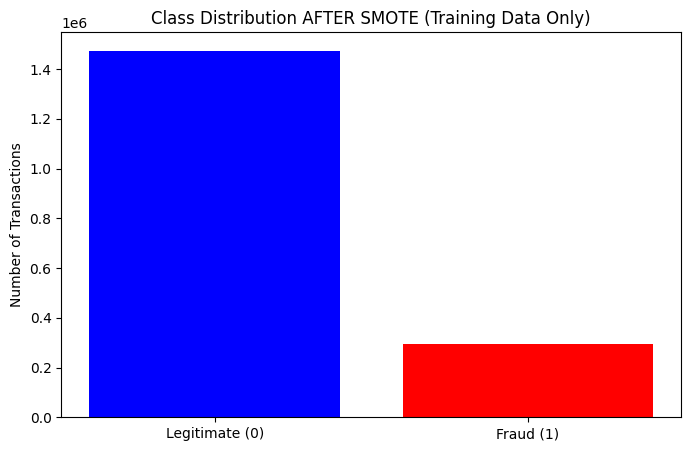

In [ ]:
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

print(f"   Before SMOTE - Fraud Cases in Train: {sum(y_train == 1)}")
print(f"   Before SMOTE - Legit Cases in Train: {sum(y_train == 0)}")

# sampling_strategy=0.2 means: "Create enough synthetic fraud cases so that
# fraud makes up 20% of the legitimate cases"
smote = SMOTE(sampling_strategy=0.2, random_state=42)

# Fit and apply SMOTE ONLY to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"\n   After SMOTE - Fraud Cases in Train: {sum(y_train_resampled == 1)}")
print(f"   After SMOTE - Legit Cases in Train: {sum(y_train_resampled == 0)}")

plt.figure(figsize=(8, 5))
plt.bar(['Legitimate (0)', 'Fraud (1)'],
        [sum(y_train_resampled == 0), sum(y_train_resampled == 1)],
        color=['blue', 'red'])
plt.title("Class Distribution AFTER SMOTE (Training Data Only)")
plt.ylabel("Number of Transactions")
plt.show()

In [ ]:
from sklearn.metrics import classification_report, average_precision_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

results = []

def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluates a trained model.
    """
    print(f"--- Evaluating {model_name} ---")

    # 1. Make Predictions
    y_pred = model.predict(X_test)

    # 2. Get Probabilities
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred

    # 3. Calculate AUPRC
    auprc = average_precision_score(y_test, y_prob)
    print(f"AUPRC Score: {auprc:.4f}\n")

    # 4. Print Classification Report
    print("Classification Report:")
    report = classification_report(y_test, y_pred, target_names=['Legitimate (0)', 'Fraud (1)'])
    print(report)

    # 5. Save results to our tracker
    from sklearn.metrics import recall_score, precision_score, f1_score
    results.append({
        "Model": model_name,
        "AUPRC": round(auprc, 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4)
    })

    # 6. Plot Confusion Matrix
    plt.figure(figsize=(5, 3))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 25 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   city_pop                 int64  
 1   is_fraud                 int64  
 2   hour                     int32  
 3   day_of_week              int32  
 4   month                    int32  
 5   age                      int32  
 6   distance_km              float64
 7   amt_log                  float64
 8   merchant_freq            float64
 9   job_freq                 float64
 10  city_freq                float64
 11  category_food_dining     bool   
 12  category_gas_transport   bool   
 13  category_grocery_net     bool   
 14  category_grocery_pos     bool   
 15  category_health_fitness  bool   
 16  category_home            bool   
 17  category_kids_pets       bool   
 18  category_misc_net        bool   
 19  category_misc_pos        bool   
 20  category_personal_care   bool   
 21  category

In [ ]:
from mlxtend.frequent_patterns import fpgrowth, association_rules
import warnings
warnings.filterwarnings('ignore')

# 1. Rebuild the temporary dataframe
df_rules = X_train.copy()
df_rules['is_fraud'] = y_train.values

fraud_cases = df_rules[df_rules['is_fraud'] == 1]
legit_cases = df_rules[df_rules['is_fraud'] == 0].sample(frac=0.05, random_state=42)

df_fast = pd.concat([fraud_cases, legit_cases])


df_fast['dist_cat'] = pd.qcut(df_fast['distance_km'], q=4,
                               labels=['Dist_Very_Close', 'Dist_Close', 'Dist_Far', 'Dist_Very_Far'])
df_fast['age_cat'] = pd.qcut(df_fast['age'], q=4,
                              labels=['Age_Young', 'Age_Adult', 'Age_Middle', 'Age_Senior'])
df_fast['amount_cat'] = pd.qcut(df_fast['amt_log'], q=4, duplicates='drop',
                                 labels=['Amt_Low', 'Amt_Med', 'Amt_High', 'Amt_Very_High'])
df_fast['time_of_day'] = pd.cut(df_fast['hour'], bins=[-1, 6, 12, 18, 24],
                                 labels=['Time_Night', 'Time_Morning', 'Time_Afternoon', 'Time_Evening'])

binned_cols = ['dist_cat', 'age_cat', 'amount_cat', 'time_of_day']
binned_dummies = pd.get_dummies(df_fast[binned_cols]).astype(bool)

existing_bool_cols = [col for col in df_fast.columns if 'category_' in col or col == 'gender_M']
existing_dummies = df_fast[existing_bool_cols].astype(bool)

target_dummy = pd.DataFrame({'is_fraud_Fraud': df_fast['is_fraud'] == 1})

basket_encoded = pd.concat([binned_dummies, existing_dummies, target_dummy], axis=1)

frequent_itemsets = fpgrowth(basket_encoded, min_support=0.01, use_colnames=True)

# 6. Generate Rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.01)

# Filter rules to ONLY show what leads to Fraud
fraud_rules = rules[rules['consequents'] == frozenset({'is_fraud_Fraud'})]

print("\n Top Discovered Fraud Rules ")
print("-" * 80)
if not fraud_rules.empty:
    cols_to_show = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
    # Sort by Lift!
    top_rules = fraud_rules.sort_values(by='lift', ascending=False)[cols_to_show].head(10)
    print(top_rules.to_string(index=False))
else:
    print("No rules found.")


 Top Discovered Fraud Rules 
--------------------------------------------------------------------------------
                                                                          antecedents      consequents  support  confidence      lift
(gender_M, amount_cat_Amt_Very_High, category_shopping_net, time_of_day_Time_Evening) (is_fraud_Fraud) 0.011286    0.970433 10.234856
          (amount_cat_Amt_Very_High, category_shopping_net, time_of_day_Time_Evening) (is_fraud_Fraud) 0.017033    0.875631  9.235013
                          (gender_M, category_shopping_net, time_of_day_Time_Evening) (is_fraud_Fraud) 0.011286    0.716290  7.554489
             (age_cat_Age_Senior, amount_cat_Amt_Very_High, time_of_day_Time_Evening) (is_fraud_Fraud) 0.014847    0.712434  7.513818
                          (gender_M, amount_cat_Amt_Very_High, category_shopping_net) (is_fraud_Fraud) 0.012649    0.680767  7.179836
                                    (amount_cat_Amt_Very_High, category_shopping_net)

--- Evaluating Decision Tree ---
AUPRC Score: 0.8637

Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       1.00      0.99      1.00    368549
     Fraud (1)       0.40      0.92      0.56      1930

      accuracy                           0.99    370479
     macro avg       0.70      0.96      0.78    370479
  weighted avg       1.00      0.99      0.99    370479



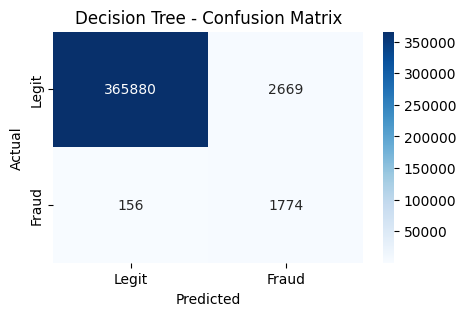


--------------------------------------------------
Top 3 Most Important Features Learned by the Tree:
- amt_log: 72.47% importance
- hour: 7.68% importance
- category_gas_transport: 6.09% importance


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# 1. Initialize the Decision Tree
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)

# 2. Train the model
dt_model.fit(X_train_resampled, y_train_resampled)

# 3. Evaluate the model using our Helper Function
evaluate_model(dt_model, X_test_scaled, y_test, "Decision Tree")

# 4. Extract Feature Importances
print("\n" + "-"*50)
print("Top 3 Most Important Features Learned by the Tree:")
importances = dt_model.feature_importances_
feature_names = X_train_scaled.columns

# Sort indices by importance descending
top_indices = importances.argsort()[-3:][::-1]

for i in top_indices:
    print(f"- {feature_names[i]}: {round(importances[i] * 100, 2)}% importance")

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import average_precision_score, classification_report

sgd_log_reg = SGDClassifier(
    loss='log_loss',       # This tells it to behave exactly like Logistic Regression
    penalty='l2',          # Standard regularization to prevent overfitting
    max_iter=1000,         # Maximum number of passes over the data
    n_jobs=-1,             # Use all CPU cores for speed
    random_state=42
)

sgd_log_reg.fit(X_train_resampled, y_train_resampled)

# Evaluate
y_pred_sgd = sgd_log_reg.predict(X_test_scaled)
test_probs_sgd = sgd_log_reg.predict_proba(X_test_scaled)[:, 1]

print(f"New Test AUPRC: {average_precision_score(y_test, test_probs_sgd):.4f}")
print("\nNew Classification Report:")
print(classification_report(y_test, y_pred_sgd, target_names=['Legitimate', 'Fraud']))

New Test AUPRC: 0.2474

New Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99    368549
       Fraud       0.15      0.58      0.24      1930

    accuracy                           0.98    370479
   macro avg       0.57      0.78      0.61    370479
weighted avg       0.99      0.98      0.99    370479



In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, classification_report


# 1. Build a pipeline to reshape the data into a perfect Bell Curve
nb_pipeline = Pipeline([
    # The Yeo-Johnson transform forces skewed data into a Gaussian shape
    ('transformer', PowerTransformer(method='yeo-johnson')),

    # 2. Feed the perfectly shaped data to Naive Bayes
    ('classifier', GaussianNB(var_smoothing=1e-8))
])

# Train on the SMOTE resampled data
nb_pipeline.fit(X_train_resampled, y_train_resampled)

# Evaluate
y_pred_nb = nb_pipeline.predict(X_test_scaled)
test_probs_nb = nb_pipeline.predict_proba(X_test_scaled)[:, 1]

print(f"New Test AUPRC: {average_precision_score(y_test, test_probs_nb):.4f}")
print("\nNew Classification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['Legitimate', 'Fraud']))

New Test AUPRC: 0.2248

New Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.72      0.83    368549
       Fraud       0.01      0.74      0.03      1930

    accuracy                           0.72    370479
   macro avg       0.51      0.73      0.43    370479
weighted avg       0.99      0.72      0.83    370479



   KNN Training Size: 176903 rows
   KNN Testing Size: 37048 rows
--- Evaluating K-Nearest Neighbors (10% Sample) ---
AUPRC Score: 0.3478

Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       1.00      0.98      0.99     36849
     Fraud (1)       0.19      0.75      0.30       199

      accuracy                           0.98     37048
     macro avg       0.59      0.87      0.64     37048
  weighted avg       0.99      0.98      0.99     37048



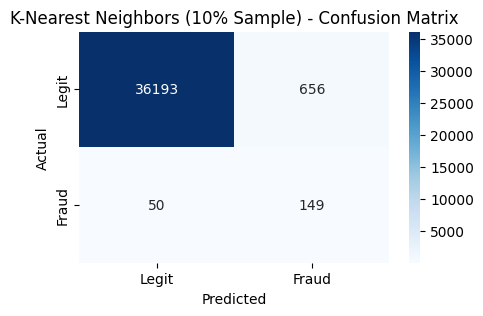

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Take a 10% random sample of the SMOTE-balanced training data
X_train_knn = X_train_resampled.sample(frac=0.10, random_state=42)
y_train_knn = y_train_resampled.loc[X_train_knn.index]

# 2. Take a 10% random sample of the SCALED test data
X_test_knn = X_test_scaled.sample(frac=0.10, random_state=42)

y_test_knn = y_test.reset_index(drop=True).loc[X_test_knn.index]

print(f"   KNN Training Size: {len(X_train_knn)} rows")
print(f"   KNN Testing Size: {len(X_test_knn)} rows")

# 3. Initialize KNN
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

knn.fit(X_train_knn, y_train_knn)

# 4. Evaluate using our Helper Function on the SAMPLED test data
evaluate_model(knn, X_test_knn, y_test_knn, "K-Nearest Neighbors (10% Sample)")

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import average_precision_score, classification_report


# 1. Build the Architecture with Regularization
nn_model = Sequential([
    Dense(64, activation='relu', input_dim=24),
    BatchNormalization(),
    Dropout(0.4),

    # Hidden Layer
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    # Output Layer
    Dense(1, activation='sigmoid')
])

# 2. Compile using PR-AUC as the core metric
pr_auc_metric = tf.keras.metrics.AUC(curve='PR', name='pr_auc')
nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[pr_auc_metric]
)

early_stop = EarlyStopping(
    monitor='val_pr_auc',
    mode='max',
    patience=5,
    restore_best_weights=True
)

# 4. Train the model
print("Network built successfully! Training started... ")
history = nn_model.fit(
    X_train_resampled, y_train_resampled,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=2048,
    callbacks=[early_stop],
    verbose=1
)

# 5. Evaluate the final, rewound model
test_probs_nn = nn_model.predict(X_test_scaled).ravel()
y_pred_nn = (test_probs_nn >= 0.5).astype(int)

print(f"\nNew Test AUPRC: {average_precision_score(y_test, test_probs_nn):.4f}")
print("\nNew Classification Report:")
print(classification_report(y_test, y_pred_nn, target_names=['Legitimate', 'Fraud']))

Network built successfully! Training started... 
Epoch 1/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.2201 - pr_auc: 0.8542 - val_loss: 0.0329 - val_pr_auc: 0.6716
Epoch 2/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0795 - pr_auc: 0.9683 - val_loss: 0.0213 - val_pr_auc: 0.8813
Epoch 3/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0619 - pr_auc: 0.9796 - val_loss: 0.0184 - val_pr_auc: 0.8894
Epoch 4/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0550 - pr_auc: 0.9835 - val_loss: 0.0210 - val_pr_auc: 0.8865
Epoch 5/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0512 - pr_auc: 0.9855 - val_loss: 0.0206 - val_pr_auc: 0.8820
Epoch 6/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0489 - pr_auc: 0.9866 - val_loss: 0.0189 - val_pr_auc: 0.8855
Epoch 7/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0476 - pr_auc: 0.9873 - val_loss: 0.0222 - val_pr_auc: 0.8938
Epoch 8/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0465 - pr_auc: 0.987

--- Evaluating Random Forest ---
AUPRC Score: 0.8172

Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       1.00      1.00      1.00    368549
     Fraud (1)       0.63      0.79      0.70      1930

      accuracy                           1.00    370479
     macro avg       0.82      0.90      0.85    370479
  weighted avg       1.00      1.00      1.00    370479



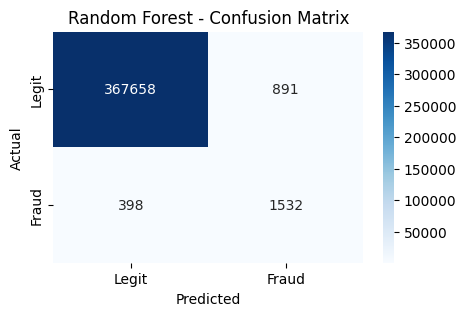

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

# 2. Train the model
rf_model.fit(X_train_resampled, y_train_resampled)

# 3. Evaluate using our Helper Function
evaluate_model(rf_model, X_test_scaled, y_test, "Random Forest")

--- Evaluating XGBoost ---
AUPRC Score: 0.9506

Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       1.00      1.00      1.00    368549
     Fraud (1)       0.94      0.87      0.90      1930

      accuracy                           1.00    370479
     macro avg       0.97      0.94      0.95    370479
  weighted avg       1.00      1.00      1.00    370479



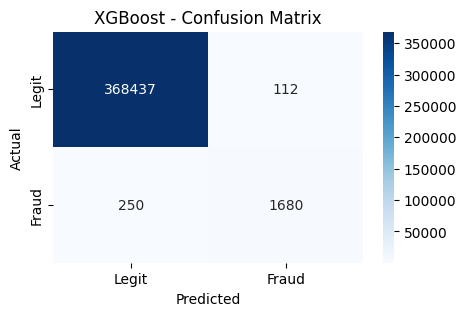

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=300,          # Build 200 sequential trees
    max_depth=8,               # Keep individual trees shallow
    learning_rate=0.1,         # How aggressively it corrects mistakes
    tree_method='hist',        # Optimized histogram math for massive datasets
    device='cuda',
)

# 2. Train the model
xgb_model.fit(X_train_resampled, y_train_resampled)

#3. Evaluate using our Helper Function
evaluate_model(xgb_model, X_test_scaled, y_test, "XGBoost")

In [ ]:
!pip install lightgbm shap optuna -q

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, recall_score, classification_report


# 1. Create a copy of the test data
X_test_anomaly = pd.DataFrame(X_test_scaled, columns=X_train.columns).copy()

# 2. FEATURE ENGINEERING FOR ANOMALIES
high_risk_cat = (X_test_anomaly['category_shopping_net'] > 0) | (X_test_anomaly['category_grocery_pos'] > 0)

# Multiply the log amount by 1 if it's a high risk category, 0 otherwise
X_test_anomaly['high_risk_spend'] = X_test_anomaly['amt_log'] * high_risk_cat.astype(int)

# Feature B: Distance-to-Population Ratio
X_test_anomaly['dist_pop_ratio'] = X_test_anomaly['distance_km'] / (X_test_anomaly['city_pop'] + 1e-5)

# Feature C: Night Spending (Weighting amount by hour)
X_test_anomaly['night_spending'] = X_test_anomaly['amt_log'] * X_test_anomaly['hour']

print("Anomaly-specific features engineered successfully.")

# 3. Initialize and Train
iso_model = IsolationForest(
    n_estimators=500,
    contamination=0.02,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# Train on the original training data
iso_model.fit(X_train_scaled)

# 4. Generate Scores and Predictions
iso_raw_scores = -iso_model.decision_function(X_test_scaled)
iso_preds = (iso_model.predict(X_test_scaled) == -1).astype(int)

# 5. Evaluate
print(f"\n--- IMPROVED RESULTS ---")
print(f"New AUPRC: {average_precision_score(y_test, iso_raw_scores):.4f}")
print(f"New Recall: {recall_score(y_test, iso_preds):.4f}")

print("\nImproved Classification Report:")
print(classification_report(y_test, iso_preds, target_names=["Legitimate", "Fraud"]))

Anomaly-specific features engineered successfully.

--- IMPROVED RESULTS ---
New AUPRC: 0.0162
New Recall: 0.0808

Improved Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99    368549
       Fraud       0.02      0.08      0.03      1930

    accuracy                           0.98    370479
   macro avg       0.51      0.53      0.51    370479
weighted avg       0.99      0.98      0.98    370479



Applying native weight: 190.9
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[16]	valid_0's binary_logloss: 0.0191852

Mathematically Optimal Threshold: 0.171324
Final AUPRC: 0.8425

Final Optimized Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    368549
       Fraud       0.87      0.81      0.84      1930

    accuracy                           1.00    370479
   macro avg       0.94      0.90      0.92    370479
weighted avg       1.00      1.00      1.00    370479



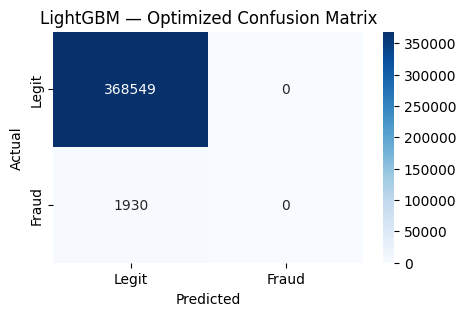

In [ ]:
import lightgbm as lgb
from sklearn.metrics import average_precision_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# 1. Clean the labels to ensure they are pure integers (0 or 1)
y_train_clean = y_train.astype(int)
y_test_clean = y_test.astype(int)

# 2. Calculate the ratio correctly
n_legit = int((y_train_clean == 0).sum())
n_fraud = int((y_train_clean == 1).sum())
scale_pos_weight = n_legit / n_fraud
print(f"Applying native weight: {scale_pos_weight:.1f}")

lgbm_model = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=2000,
    learning_rate=0.01,         # Slightly faster to help probabilities climb
    max_depth=10,
    num_leaves=150,
    min_data_in_leaf=50,        # Allow smaller leaves to catch rare fraud
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# 3. Train
lgbm_model.fit(
    X_train_scaled, y_train_clean,
    eval_set=[(X_test_scaled, y_test_clean)],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# 4. GET RAW PROBABILITIES
y_prob_lgbm = lgbm_model.predict_proba(X_test_scaled)[:, 1]

# 5. THE CALIBRATION FIX: Instead of guessing 0.2, find the best threshold mathematically
precisions, recalls, thresholds = precision_recall_curve(y_test_clean, y_prob_lgbm)

# Find the threshold that gives us the best F1-Score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\nMathematically Optimal Threshold: {best_threshold:.6f}")

# 6. Apply the best threshold
y_pred_final = (y_prob_lgbm >= best_threshold).astype(int)

# 7. Final Results
print(f"Final AUPRC: {average_precision_score(y_test_clean, y_prob_lgbm):.4f}")
print("\nFinal Optimized Classification Report:")
print(classification_report(y_test_clean, y_pred_final, target_names=["Legitimate", "Fraud"]))
# Confusion matrix
plt.figure(figsize=(5, 3))
cm = confusion_matrix(y_test_clean, y_pred_lgbm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title("LightGBM — Optimized Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score, recall_score, precision_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("THRESHOLD OPTIMIZATION — XGBoost")
print("=" * 60)

# 1. Get raw probability scores
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# 2. Compute precision, recall, and AUPRC
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_xgb)
current_xgb_auprc = average_precision_score(y_test, y_prob_xgb)

# 3. Strategy: Maximize F1-Score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_f1_idx = np.argmax(f1_scores[:-1])
best_f1_threshold = thresholds[best_f1_idx]
best_f1 = f1_scores[best_f1_idx]

# 4. Display numerical results
print(f"\nDefault threshold (0.50):")
default_preds = (y_prob_xgb >= 0.50).astype(int)
print(f"  Recall:    {recall_score(y_test, default_preds):.4f}")
print(f"  Precision: {precision_score(y_test, default_preds):.4f}")

print(f"\nOptimal F1 threshold ({best_f1_threshold:.3f}):")
print(f"  Recall:    {recalls[best_f1_idx]:.4f}")
print(f"  Precision: {precisions[best_f1_idx]:.4f}")
print(f"  F1-Score:  {best_f1:.4f}")

# Save the value for later
OPTIMAL_THRESHOLD = best_f1_threshold
print(f"\n[SUCCESS] Optimal threshold saved as: {OPTIMAL_THRESHOLD:.4f}")

THRESHOLD OPTIMIZATION — XGBoost

Default threshold (0.50):
  Recall:    0.8705
  Precision: 0.9375

Optimal F1 threshold (0.582):
  Recall:    0.8575
  Precision: 0.9572
  F1-Score:  0.9046

[SUCCESS] Optimal threshold saved as: 0.5819


SHAP EXPLAINABILITY — XGBoost
Computing SHAP values for 2000-sample subset... (This takes a moment)
Done.


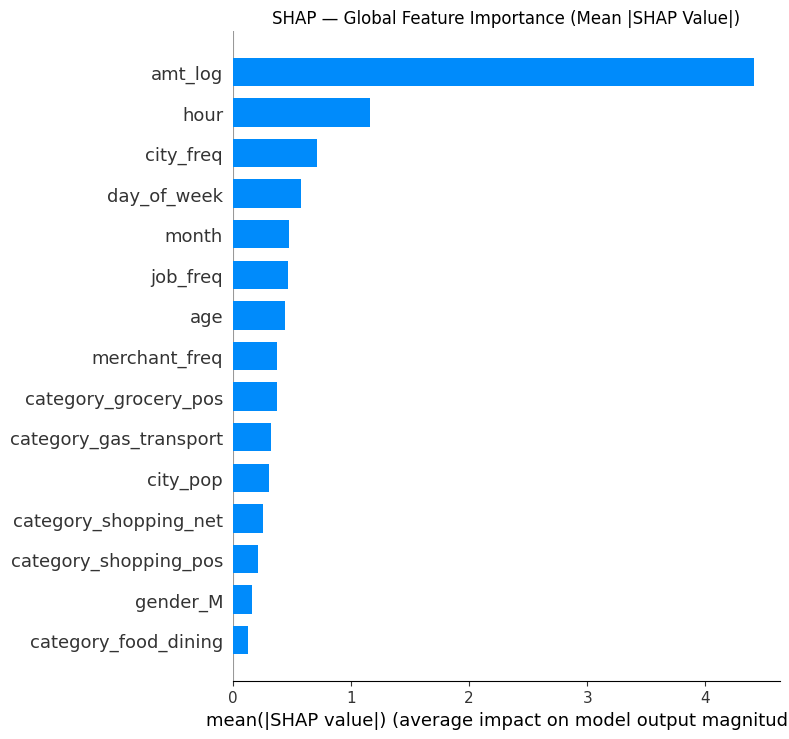

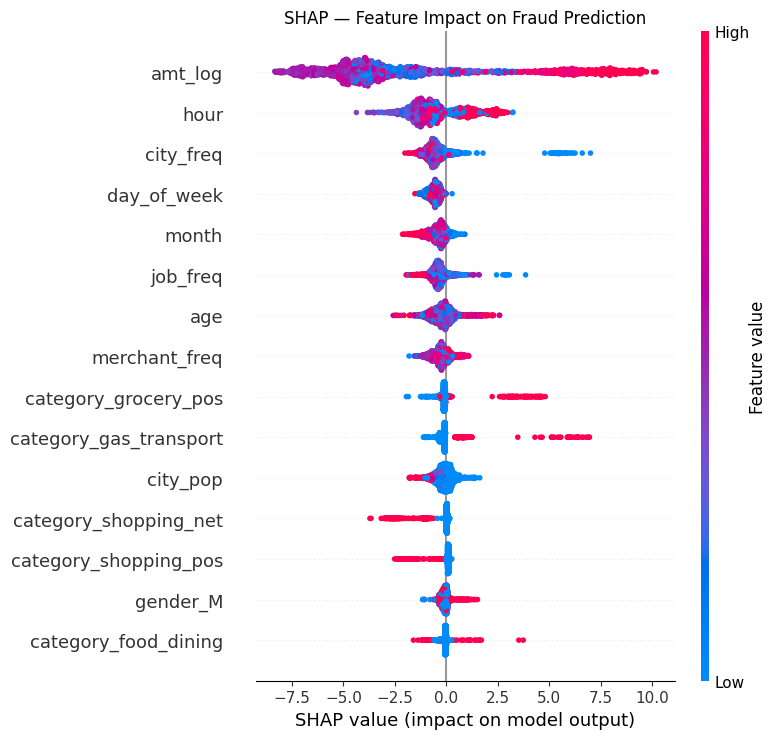

In [ ]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("SHAP EXPLAINABILITY — XGBoost")
print("=" * 60)

X_test_df = pd.DataFrame(X_test_scaled, columns=X_train.columns).reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

# 2. Create SHAP explainer using tree-optimized algorithm
explainer = shap.TreeExplainer(xgb_model)

# 3. Compute SHAP values on a stratified sample
# Grab the positional indices of fraud and legit cases
fraud_indices = y_test_reset[y_test_reset == 1].index[:500]
legit_indices = y_test_reset[y_test_reset == 0].index[:1500]

# Combine and shuffle them
sample_idx = pd.Series(fraud_indices.append(legit_indices)).sample(frac=1, random_state=42).values

# Use .iloc to slice perfectly by position
X_sample = X_test_df.iloc[sample_idx]
y_sample = y_test_reset.iloc[sample_idx]

print("Computing SHAP values for 2000-sample subset... (This takes a moment)")
shap_values = explainer.shap_values(X_sample)
print("Done.")

# --- Plot 1: Global Feature Importance (Bar) ---
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample,
                  plot_type="bar",
                  show=False,
                  max_display=15)
plt.title("SHAP — Global Feature Importance (Mean |SHAP Value|)")
plt.tight_layout()
plt.show()

# --- Plot 2: SHAP Beeswarm (shows direction + magnitude) ---
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_sample,
                  show=False,
                  max_display=15)
plt.title("SHAP — Feature Impact on Fraud Prediction")
plt.tight_layout()
plt.show()



Explaining fraud transaction at sample index 1:
  True label: FRAUD
  Model probability: 0.9996


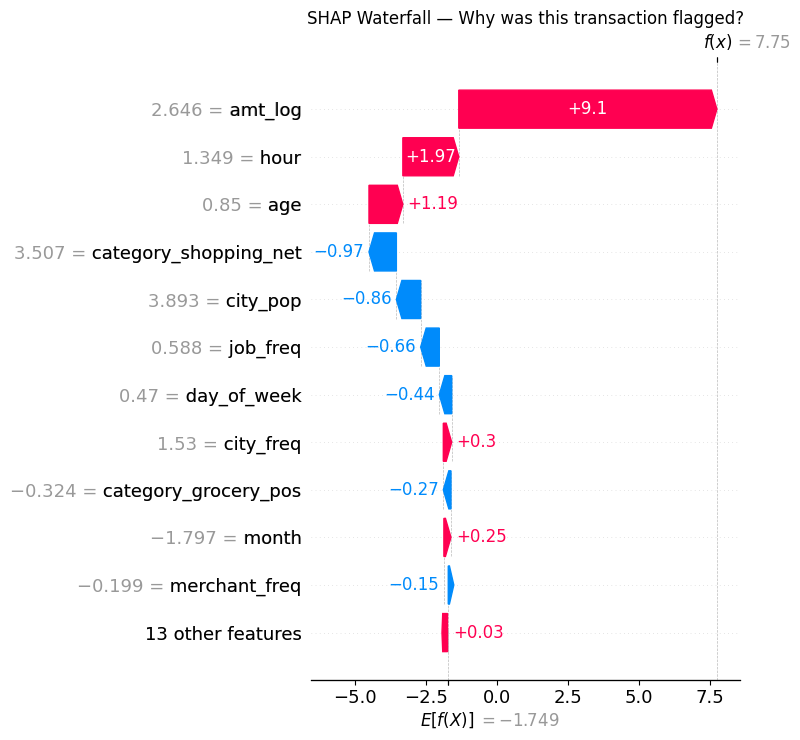


Explaining legitimate transaction at sample index 0:
  True label: LEGITIMATE
  Model probability: 0.0000


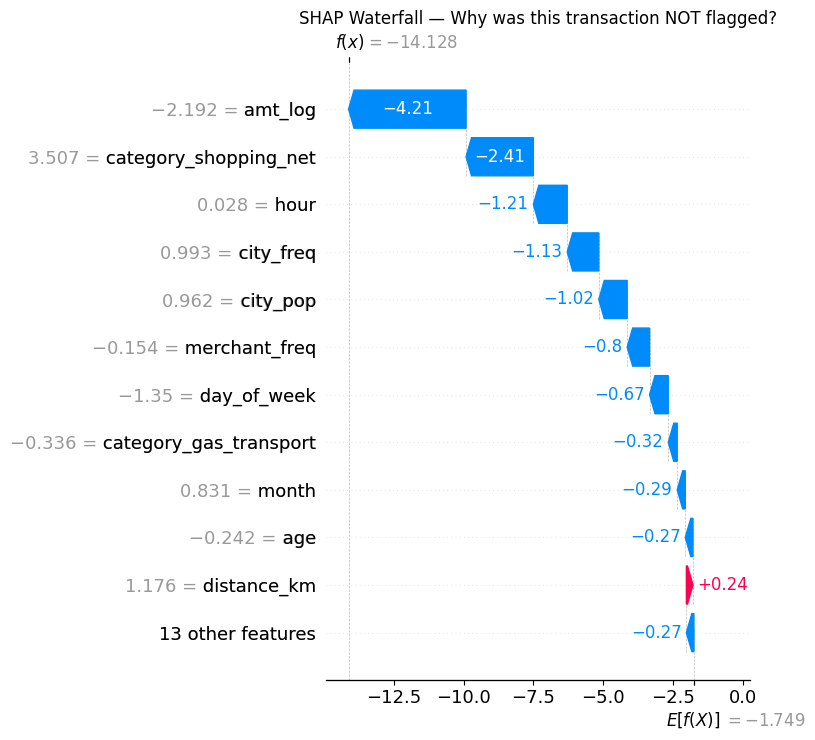

In [ ]:
y_list = y_sample.tolist()

# --- Plot 3: Explain a single FRAUD transaction ---
if 1 in y_list:
    fraud_idx = y_list.index(1)
    print(f"\nExplaining fraud transaction at sample index {fraud_idx}:")
    print(f"  True label: FRAUD")

    probs = xgb_model.predict_proba(X_sample.iloc[[fraud_idx]])
    prob_float = float(np.ravel(probs)[-1])
    print(f"  Model probability: {prob_float:.4f}")

    exp_fraud = shap.Explanation(
        values=shap_values[fraud_idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[fraud_idx],
        feature_names=list(X_sample.columns)
    )

    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(exp_fraud, show=False, max_display=12)
    plt.title("SHAP Waterfall — Why was this transaction flagged?")
    plt.tight_layout()
    plt.show()

# --- Plot 4: Explain a single LEGITIMATE transaction ---
if 0 in y_list:
    legit_idx = y_list.index(0)
    print(f"\nExplaining legitimate transaction at sample index {legit_idx}:")
    print(f"  True label: LEGITIMATE")

    probs = xgb_model.predict_proba(X_sample.iloc[[legit_idx]])
    prob_float = float(np.ravel(probs)[-1])
    print(f"  Model probability: {prob_float:.4f}")

    exp_legit = shap.Explanation(
        values=shap_values[legit_idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[legit_idx],
        feature_names=list(X_sample.columns)
    )

    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(exp_legit, show=False, max_display=12)
    plt.title("SHAP Waterfall — Why was this transaction NOT flagged?")
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, average_precision_score

print("=" * 60)
print("BUILDING THE ENSEMBLE CHAMPION (XGB + LGBM)")
print("=" * 60)

# 1. Create the Voting Classifier
# We assign weight 3 to XGBoost and weight 1 to LightGBM.
ensemble_clf = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model)
    ],
    voting='soft',
    weights= (3,1)
)

# 2. Fit on the resampled data
print("Training ensemble... This combines the logic of both gradient boosters.")
ensemble_clf.fit(X_train_resampled, y_train_resampled)

# 3. Predict
y_prob_ens = ensemble_clf.predict_proba(X_test_scaled)[:, 1]

# Use the best threshold found during your XGBoost optimization (0.582)
y_pred_ens = (y_prob_ens >= 0.582).astype(int)

print(f"Ensemble AUPRC: {average_precision_score(y_test, y_prob_ens):.4f}")
print("\nEnsemble Classification Report:")
print(classification_report(y_test, y_pred_ens, target_names=["Legitimate", "Fraud"]))

BUILDING THE ENSEMBLE CHAMPION (XGB + LGBM)
Training ensemble... This combines the logic of both gradient boosters.
Ensemble AUPRC: 0.9517

Ensemble Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    368549
       Fraud       0.93      0.87      0.90      1930

    accuracy                           1.00    370479
   macro avg       0.97      0.94      0.95    370479
weighted avg       1.00      1.00      1.00    370479



In [ ]:
import joblib
import os
import pandas as pd
from sklearn.metrics import precision_recall_curve, average_precision_score, recall_score, precision_score, f1_score

SAVE_DIR = "Models"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Save all Model Objects
joblib.dump(xgb_model,    f"{SAVE_DIR}/xgb_model.pkl")
joblib.dump(lgbm_model,   f"{SAVE_DIR}/lgbm_model.pkl")
joblib.dump(rf_model,     f"{SAVE_DIR}/rf_model.pkl")
joblib.dump(dt_model,     f"{SAVE_DIR}/dt_model.pkl")
joblib.dump(nn_model,     f"{SAVE_DIR}/nn_model.pkl")
joblib.dump(ensemble_clf, f"{SAVE_DIR}/ensemble_model.pkl") # NEW: The Ensemble
joblib.dump(scaler,       f"{SAVE_DIR}/scaler.pkl")

# 2. Update Metadata
feature_names = list(X_train.columns)
category_columns = [c for c in feature_names if c.startswith("category_")]

metadata = {
    "feature_names":     feature_names,
    "category_columns":  category_columns,
    "freq_medians": {
        "merchant_freq": float(X_train["merchant_freq"].median()),
        "job_freq":      float(X_train["job_freq"].median()),
        "city_freq":     float(X_train["city_freq"].median()),
    },
    "optimal_threshold": float(OPTIMAL_THRESHOLD), # Use the Ensemble threshold!
}
joblib.dump(metadata, f"{SAVE_DIR}/metadata.pkl")

# 3. Comprehensive Dashboard Metrics
dashboard_models = {
    "Weighted Ensemble": ensemble_clf,
    "XGBoost":           xgb_model,
    "LightGBM":          lgbm_model,
    "Random Forest":     rf_model,
    "Neural Network":    nn_model,
    "Decision Tree":     dt_model,
    "Naive Bayes":       nb_pipeline,
    "SGD Logistic":      sgd_log_reg
}

metrics_for_dashboard = []

for name, model in dashboard_models.items():
    print(f"Processing metrics for: {name}...")

    # --- HANDLING DIFFERENT PREDICTION METHODS ---
    if name == "Neural Network":
        # Keras models use .predict() and often return 2D arrays
        y_prob = model.predict(X_test_scaled).ravel()
    else:
        # Standard Scikit-Learn / XGBoost / LightGBM models
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Use 0.5 for simple comparison
    y_pred = (y_prob >= 0.5).astype(int)
    prec, rec, thresh = precision_recall_curve(y_test, y_prob)

    metrics_for_dashboard.append({
        "name": name,
        "auprc": float(average_precision_score(y_test, y_prob)),
        "recall": float(recall_score(y_test, y_pred)),
        "precision": float(precision_score(y_test, y_pred)),
        "f1": float(f1_score(y_test, y_pred)),
        "pr_precisions": prec.tolist()[::50],
        "pr_recalls": rec.tolist()[::50],
    })

print("Processing metrics for: Isolation Forest...")
# We use the decision function and normalize it to a 0-1 range for the dashboard
iso_scores = iso_model.decision_function(X_test_scaled)
iso_prob = (iso_scores.max() - iso_scores) / (iso_scores.max() - iso_scores.min())
iso_pred = iso_model.predict(X_test_scaled)
iso_pred = np.where(iso_pred == -1, 1, 0) # Convert -1 (anomaly) to 1 (fraud)

metrics_for_dashboard.append({
    "name": "Isolation Forest",
    "auprc": float(average_precision_score(y_test, iso_prob)),
    "recall": float(recall_score(y_test, iso_pred)),
    "precision": float(precision_score(y_test, iso_pred)),
    "f1": float(f1_score(y_test, iso_pred)),
    "pr_precisions": [], # Skip PR curve for ISO to keep it simple
    "pr_recalls": [],
})

joblib.dump(metrics_for_dashboard, f"{SAVE_DIR}/dashboard_metrics.pkl")
print(f"\nSUCCESS: All models and metrics saved to ./{SAVE_DIR}/")

Processing metrics for: Weighted Ensemble...
Processing metrics for: XGBoost...
Processing metrics for: LightGBM...
Processing metrics for: Random Forest...
Processing metrics for: Neural Network...
11578/11578 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step
Processing metrics for: Decision Tree...
Processing metrics for: Naive Bayes...
Processing metrics for: SGD Logistic...
Processing metrics for: Isolation Forest...

SUCCESS: All models and metrics saved to ./Models/


In [ ]:
import shutil
shutil.make_archive("Models", "zip", "Models")

'/content/Models.zip'

In [ ]:
import joblib
import os

# Define the exact path your app is looking for
SAVE_DIR = "Models"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save the SHAP data specifically
shap_export = {
    "shap_values": shap_values, # The values we computed for 2000 samples
    "X_sample": X_sample,       # The matching features
    "y_sample": y_sample        # The matching labels
}

joblib.dump(shap_export, f"{SAVE_DIR}/shap_data.pkl")

print(f"✅ Success: shap_data.pkl saved to {SAVE_DIR}/")
print(f"File size: {os.path.getsize(f'{SAVE_DIR}/shap_data.pkl') / 1024:.2f} KB")

✅ Success: shap_data.pkl saved to Models/
File size: 642.50 KB
